# Portfolio Part 4

***Can we identify any trends in student attendance patterns using date information?***

In this Portfolio task, you will work on a dataset named '2018-2019_Daily_Attendance_20240429', it contains data about School indentifcation numbers, dates, enrolled students, present or abscent and released students. Your main task is to train models to predict any seasonal trends in Student attendence patterns and predict student attendence through histroical data in relation to date information and abscence trends.

This question aims to be able to predict the variation in student attendance rates accross different seasons or seasonal factors based on historical attendeance data. This analysis will provide insight into what seasonal factors may influence student attendence patterns, which may include academic schedules, holidays or weather,



|Column|Meaning|
|:--------:|:---------:|
| School DBN|School Identification number|
|Date|Calendar date of the date in the school year for which the data is being reported.|
|Enrolled| Number of students matriculated on that day.|
|Absent|The count of students whom were absent for that day.|
|Present|The count of students present in school that day.|
|Released|The count of students who were released from school for any reason on the date for which data is being reported.|

In [ ]:
student_name = "Jihoon (Eren) Choi"
student_id = "47279621"

## **Data Acquisition and Preparation:**


In [2]:
#Imports and Preparation
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

#Reading Dataset

df = pd.read_csv('/content/2018-2019_Daily_Attendance_20240429.csv')

print(df)

       School DBN      Date  Enrolled  Absent  Present  Released
0          01M015  20180905       172      19      153         0
1          01M015  20180906       171      17      154         0
2          01M015  20180907       172      14      158         0
3          01M015  20180912       173       7      166         0
4          01M015  20180913       173       9      164         0
...           ...       ...       ...     ...      ...       ...
277148     79X695  20190620       230      46      136        48
277149     79X695  20190621       226      53      128        45
277150     79X695  20190624       226      42      130        54
277151     79X695  20190625       226      56      127        43
277152     79X695  20190626       216      27       68       121

[277153 rows x 6 columns]


## **Exploratory Data Analysis (EDA):**

Explore the dataset and conduct univariate and bivariate analyses to try and identify any patterns or relationships within the attendance data, then visiaulize the attendance patterns over time to identify any trends.

In [ ]:
#Exploring Dataset & Cleaning

#display the dataset
print("\Displaying dataset")
print(df.head())

#examine the data types and general information
print("\nGeneral Information")
print(df.info())

#summary statistics
print("\nSummary Statistics")
print(df.describe())

# check the data types of each column
print("\ndatatypes of each column")
print(df.dtypes)

#check for missing values
print("\nSum of Missing values")
print(df.isnull().sum())

#Dropping missing values
cleandf = df.dropna()

# Display the shape of the dataset
print("Shape of the dataset:", df.shape)


\Displaying dataset
  School DBN      Date  Enrolled  Absent  Present  Released
0     01M015  20180905       172      19      153         0
1     01M015  20180906       171      17      154         0
2     01M015  20180907       172      14      158         0
3     01M015  20180912       173       7      166         0
4     01M015  20180913       173       9      164         0

General Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277153 entries, 0 to 277152
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   School DBN  277153 non-null  object
 1   Date        277153 non-null  int64 
 2   Enrolled    277153 non-null  int64 
 3   Absent      277153 non-null  int64 
 4   Present     277153 non-null  int64 
 5   Released    277153 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 12.7+ MB
None

Summary Statistics
               Date      Enrolled         Absent        Present       Released
count 

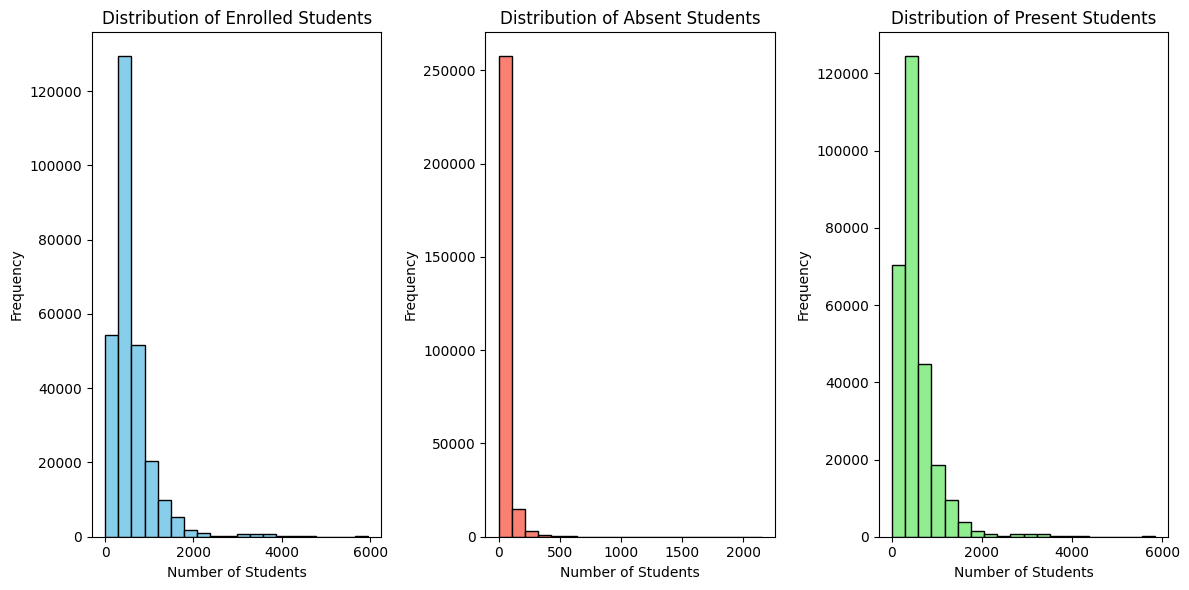

In [4]:
#Visualization of the distribution using histograms.
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.hist(df['Enrolled'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Enrolled Students')
plt.xlabel('Number of Students')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(df['Absent'], bins=20, color='salmon', edgecolor='black')
plt.title('Distribution of Absent Students')
plt.xlabel('Number of Students')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.hist(df['Present'], bins=20, color='lightgreen', edgecolor='black')
plt.title('Distribution of Present Students')
plt.xlabel('Number of Students')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

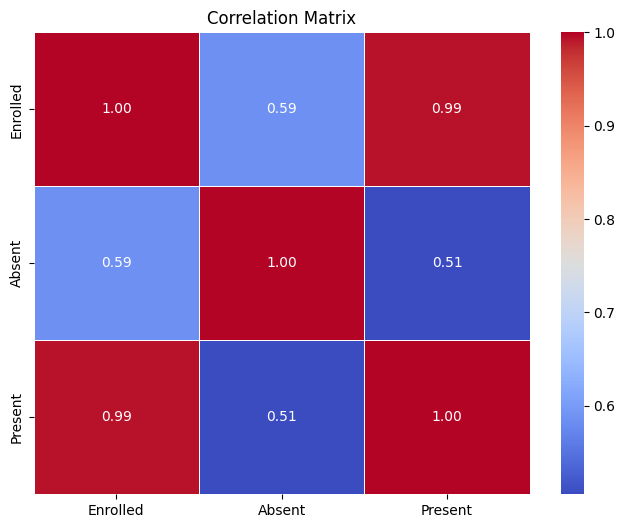

In [ ]:
# Calculating the correlation matrix
correlation_matrix = df[['Enrolled', 'Absent', 'Present']].corr()

# Heatmap visualization of the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

The correlation between these variables are not currently very high, therefore we could theorize that Enrollment, or the amount of students who are in attendance does not affect the number of absentees.

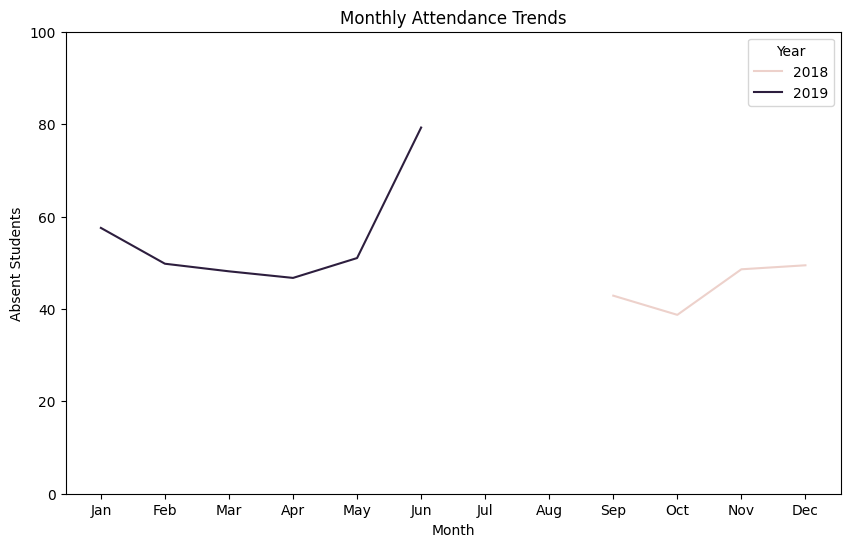

In [ ]:
# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%Y%m%d')

# Extract month and year from the 'Date' column
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# Visualize attendance patterns over time (monthly)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Month', y='Absent', hue='Year', errorbar=None)
plt.title('Monthly Attendance Trends')
plt.xlabel('Month')
plt.ylabel('Absent Students')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.ylim(0, 100)

plt.show()


There is an unusual massive increase in Absent student during the months of May-Jun(2019). May-Jun are the nearing months toward the semester break, which could entice students to not attend school. We can also notice a trend in January which slowly dies down into Febuary, since January is the beginning of school, students may be easing into school with a consistent decline of absent students until the nearing the start of May. We can notice this is a trend as in 2018, another increase of absent students appear starting from October.

#**Model Building - Linear Regression:**

Split the dataset for training and test sets using an 80:20 ratio.

Train a linear regression model to predict attendance based on seletected features,

Evaluate the model's performance by calculating the accuracy with MSE and R2 metrics.


In [ ]:
# Conversion of the "Date" variable into the date format
df['Date'] = pd.to_datetime(df['Date'], format='%Y%m%d')

#Engineering new features
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# Split the dataset into features (X) and target variable (y)
X = df[['Enrolled', 'Present', 'Day', 'Month', 'Year']]  # Features
y = df['Absent']  # Target variable

# Splitting the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the linear regression model
linear_model = LinearRegression()

# Train the model on the training set
linear_model.fit(X_train, y_train)


In [3]:
#Evaluating the model

# Predicting attendance for the training set
train_predictions = linear_model.predict(X_train)

# Calculate training set MSE
train_mse = mean_squared_error(y_train, train_predictions)
print("Training set MSE:", train_mse)

# Calculating R2 on the training set
train_r2 = r2_score(y_train, train_predictions)
print("Training set r2:", train_r2)

# Predicting attendance for the test set
test_predictions = linear_model.predict(X_test)

# Calculating test set MSE
test_mse = mean_squared_error(y_test, test_predictions)
print("Test set MSE:", test_mse)

# Calculating test set R2
test_r2 = r2_score(y_test, test_predictions)
print("Test set r2:", test_r2)

Training set mean squared error: 729.7081486315174
Training set R-squared: 0.7527508840306476
Test set mean squared error: 1026.2693146898912
Test set R-squared: 0.652498636533597


MSE
----
The MSE results indicate that the model is performing very poorly, the Training set MSE: 729.7081486315174 and the Test set MSE: 729.7081486315174 are very high for a baseline. Although the Training set MSE is a lot lower than the Test set MSE; both values are very high which may indicate the model is underfitting as it may be too simple to catch the underlying patterns.

Overall, while the linear regression model provides a reasonable fit to the training data, it exhibits higher errors when applied to the test data, suggesting potential issues with generalization.

R2 Values
---
These R-squared values indicate that the linear regression model performs reasonably well in capturing the relationship between the features and attendance patterns. However, there is a drop in performance when applying the model to unseen data (test set), suggesting that the model may be slightly overfitting to the training data.

Overall, while the linear regression model demonstrates a decent level of explanatory power, there is room for improvement, particularly in terms of generalization to unseen data.

## **Model Building - KNN:**
Train a K-Nearest Neighbors (KNN) model to predict attendance patterns based on the same selected features.


In [ ]:
# Splitting dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# KNN model instance
knn_model = KNeighborsRegressor(n_neighbors=5)  # You can adjust the number of neighbors as needed

# KNN Training
knn_model.fit(X_train, y_train)

# Predictions
train_predictions = knn_model.predict(X_train)
test_predictions = knn_model.predict(X_test)

# Evaluation

#Calculate MSE
train_mse = mean_squared_error(y_train, train_predictions)
test_mse = mean_squared_error(y_test, test_predictions)

print("Training set mean squared error:", train_mse)
print("Test set mean squared error:", test_mse)

# Calculate R2
train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score(y_test, test_predictions)

print("Training set R-squared:", train_r2)
print("Test set R-squared:", test_r2)


Training set mean squared error: 97.1805157810231
Test set mean squared error: 140.0665706914903
Training set R-squared: 0.9670720456371975
Test set R-squared: 0.9525725620023396


The KNN overall performs very well, it is able to achieve a low or lower MSE for both the training and test sets which indicates that the model is more accurately predicting the attendance patterns. Further, the high R2 value suggests that the KNN model is able to explain a large amount of the variance in the target variable, which shows its effectiveness in understanding the underlying patterns and relationships within the data.

The KNN model has lower MSE values for both the training and test sets compared ot the linear regression model. This shows that the KNN model is outperforming the linear regression models in terms of prediction. Moreover, the increase in the R2 value for both training and test sets. Outperforming the linear regression model on both criterias.

## **Model Evaluation and Interpretation:**
Compare and analyzee the performance of the linear regression and KNN models in predicting attendance patterns and highlight any differences.

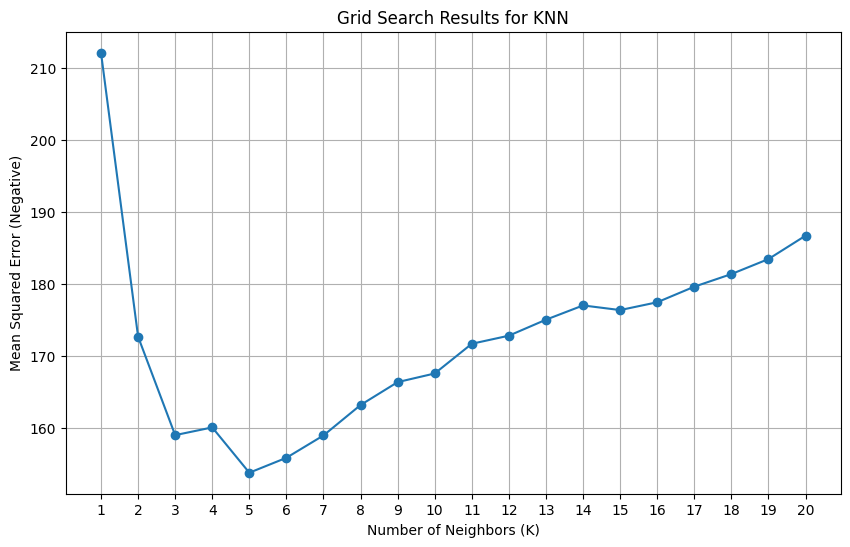

Best K: 5
Best Mean Squared Error: 153.7591207550103


In [ ]:
# K range
k_values = np.arange(1, 21)

# Parameter grid
param_grid = {'n_neighbors': k_values}

# Initializing KNN model
knn_model = KNeighborsRegressor()

# Initializing GridSearchCV
grid_search = GridSearchCV(knn_model, param_grid, cv=5, scoring='neg_mean_squared_error')

# Fitting GridsearchCV to training data
grid_search.fit(X_train, y_train)

# Visualization of the results
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(k_values, -grid_search.cv_results_['mean_test_score'], marker='o', linestyle='-')
plt.title('Grid Search Results for KNN')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Mean Squared Error (Negative)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Best K and MSE value
best_k = grid_search.best_params_['n_neighbors']
best_mse = -grid_search.best_score_
print("Best K:", best_k)
print("Best MSE:", best_mse)


## **Conclusion:**
 Summarize key findings regarding student attendance patterns.




Overall, the KNN model out performs the linear regression in terms of its predictive accuracy supported by its lower MSE score and also its higher R2 values. The linear regression model shows symptoms of overfitting as it may perform better on its training data side than its test data side. In contrast, the KNN model generalizes a lot better toward unseen data, shown by similar performance on both the training and test sets. Through these findings, I suggest that the KNN model is a definitive choice over linear regression in terms of predicting student patterns based on the given features. Although, with further optimization and analysis would be crucial to reach optimal performance on both models.

In conclusion, through the visual exploration of the attendance data it reveals a fluctuation in the amount of absent students over time. This could suggest that factors such as holidays/school break, weather, holidays or other factors may influence student attendance patterns. Through the attendeance patterns over time like seasonal or monthly variations empahsize the phases of higher or lower attendance rates. Understanding these patterns is crucial in which universities/schools can better use resources to improve attendance during these crucial periods that display a trend of lower attendance rates by preparing and strategizing plans in order to prevent or lessen these outcomes.
